# Regularization
# 정규화

## Goal

- Understand L2 Regularization
- L2 정규화 이해
- Implement cost function with penalty term
- 패널티가 포함된 cost 함수 구현
- Implement gradient descent with regularization
- 정규화 gradient descent 구현
- Compare lambda values
- lambda 값에 따른 차이 비교

In [92]:
import numpy as np
import matplotlib.pyplot as plt

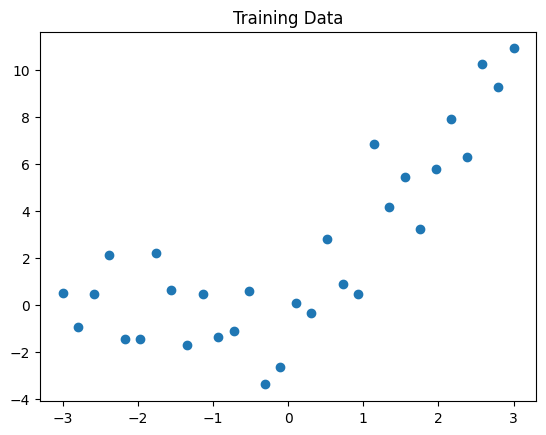

In [93]:
# 데이터 준비
np.random.seed(42)

X = np.linspace(-3, 3, 30)
y = 1 + 2*X + 0.5*(X**2) + np.random.randn(30)*2

plt.scatter(X, y)
plt.title("Training Data")
plt.show()

In [94]:
def polynomial_features(x, degree):
    features = []
    
    for d in range(1, degree+1):
        features.append(x**d)
        
    return np.column_stack(features)

In [95]:
X_train = polynomial_features(X, 4)

print(X_train.shape)

(30, 4)


In [96]:
# 예측 함수
def predict(X, w, b):
    return X @ w + b

In [97]:
# 정구화 cost
def compute_cost(X, y, w, b, lambda_):
    m = len(y)
    pred = predict(X,w,b)

    mse = np.sum((pred-y)**2)/(2*m)
    reg = lambda_ * np.sum(w**2)/(2*m)

    return mse + reg

In [98]:
def compute_gradient(X, y, w, b, lambda_):
    m = len(y)
    pred = predict(X,w,b)
    err = pred - y

    dj_dw = (X.T @ err)/m + (lambda_/m)*w
    dj_db = np.sum(err)/m

    return dj_dw, dj_db

In [99]:
def gradient_descent(X,y,w,b,alpha,iters,lambda_):
    history = []

    for i in range(iters):
        dj_dw,dj_db = compute_gradient(X,y,w,b,lambda_)

        w -= alpha*dj_dw
        b -= alpha*dj_db

        history.append(compute_cost(X,y,w,b,lambda_))

    return w,b,history

In [100]:
w = np.zeros(X_train.shape[1], dtype=float)
b = 0.0

w0, b0, hist0 = gradient_descent(
    X_train, y, w, b,
    alpha=0.001,
    iters=5000,
    lambda_=0
)

In [101]:
w1, b1, hist1 = gradient_descent(
    X_train, y, w, b,
    alpha=0.0001,
    iters=5000,
    lambda_=10
)

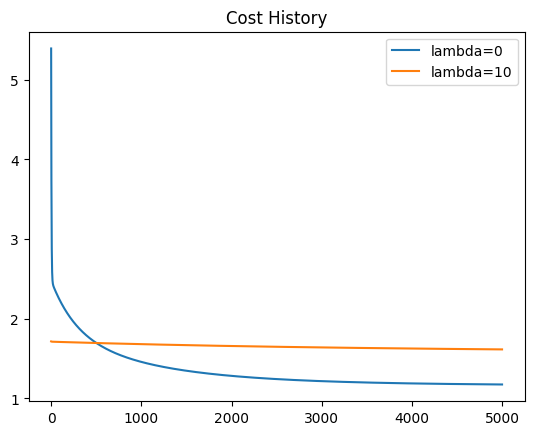

In [102]:
plt.plot(hist0, label="lambda=0")
plt.plot(hist1, label="lambda=10")
plt.legend()
plt.title("Cost History")
plt.show()

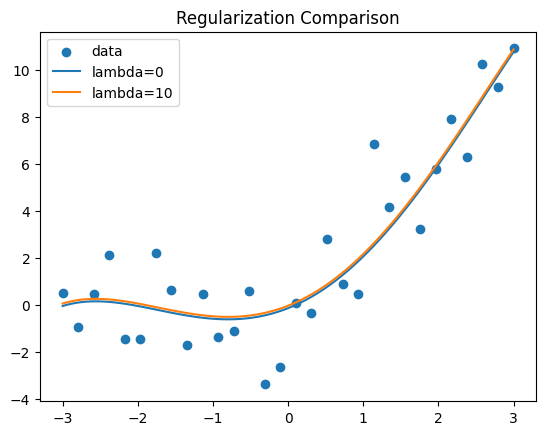

In [103]:
x_plot = np.linspace(-3,3,100)
Xp = polynomial_features(x_plot,4)

pred0 = predict(Xp, w0, b0)
pred1 = predict(Xp, w1, b1)

plt.scatter(X,y,label="data")
plt.plot(x_plot,pred0,label="lambda=0")
plt.plot(x_plot,pred1,label="lambda=10")
plt.legend()
plt.title("Regularization Comparison")
plt.show()

## Observation
## 관찰

- regularization improves generalization
- 정규화는 일반화 성능 향상에 도움된다